In [29]:
import json
import os

In [30]:
def find_perfect_blend_results(directory):
    for file in os.listdir(directory):
        if 'perfect' in file or 'bundle' in file:
            file_path = os.path.join(directory, file)
            return file_path
    return None

def find_all_perfect_blend_results(directory):
    mapping = {}
    for folder in os.listdir(directory):
        folder_path = os.path.join(directory, folder)
        result_path = find_perfect_blend_results(folder_path)
        if result_path:
            mapping[folder] = result_path
    return mapping

In [31]:
model_to_file_mapping = find_all_perfect_blend_results('/Users/franklee/Documents/Projects/Development/My-Plot/examples/data')

In [32]:
# sort the mapping by the key
model_to_file_mapping = dict(sorted(model_to_file_mapping.items()))
# print the mapping
for model, file in model_to_file_mapping.items():
    print(f"{model}: {file}")



kimi-k2: /Users/franklee/Documents/Projects/Development/My-Plot/examples/data/kimi-k2/kimi-k2-spec-bundle_results_20251220_165919.jsonl
ling-flash-v2: /Users/franklee/Documents/Projects/Development/My-Plot/examples/data/ling-flash-v2/ling-flash-v2-spec-bundle-bs-8-tp-1_results_20251221_094330.jsonl
llama3.1-8b: /Users/franklee/Documents/Projects/Development/My-Plot/examples/data/llama3.1-8b/llama3-frankleeeee-perfect-blend_results_20251216_224654.jsonl
llama3.3-70b: /Users/franklee/Documents/Projects/Development/My-Plot/examples/data/llama3.3-70b/llama3-70b-perfect-blend-regen_results_20251217_074945.jsonl
llama4-scout: /Users/franklee/Documents/Projects/Development/My-Plot/examples/data/llama4-scout/llama4-scout-spec-bundle_results_20251218_061931.jsonl
qwen3-235b-a22b: /Users/franklee/Documents/Projects/Development/My-Plot/examples/data/qwen3-235b-a22b/qwen3-235b-spec-bundle_results_20251218_203529.jsonl
qwen3-30b-a3b: /Users/franklee/Documents/Projects/Development/My-Plot/examples/d

In [33]:
def get_acceptance_length(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    gsm_results = data['gsm8k']
    results = {}
    for res in gsm_results:
        if res['steps'] == 5 and res['topk'] == 1 and res['num_draft_tokens'] == 6:
            acc_len = res['metrics'][0]['accept_length']
            output_throughput = res['metrics'][0]['output_throughput']
            results['5-1-6'] = {
                'acc_len': acc_len,
                'output_throughput': output_throughput
            }
        
        if res['steps'] == 0 and res['topk'] == 0 and res['num_draft_tokens'] == 0:
            acc_len = res['metrics'][0]['accept_length']
            output_throughput = res['metrics'][0]['output_throughput']
            results['0-0-0'] = {
                'acc_len': acc_len,
                'output_throughput': output_throughput
            }
    return results

def get_acceptance_length_from_mapping(model_to_file_mapping):
    results_mapping = {}
    for model, file in model_to_file_mapping.items():
        try:
            results = get_acceptance_length(file)
            results_mapping[model] = results
        except Exception as e:
            print(f"Error getting acceptance length for {model}: {e}")
    return results_mapping

In [34]:
# get the results mapping
results_mapping = get_acceptance_length_from_mapping(model_to_file_mapping)
# print the results mapping
for model, results in results_mapping.items():
    print(f"{model}: {results}")




Error getting acceptance length for qwen3-coder-30b-a3b: 'gsm8k'
Error getting acceptance length for qwen3-coder-480b-a35b: 'gsm8k'
kimi-k2: {'0-0-0': {'acc_len': 1.0, 'output_throughput': 337.92445122816076}, '5-1-6': {'acc_len': 4.120435815920245, 'output_throughput': 538.7660861191819}}
ling-flash-v2: {'0-0-0': {'acc_len': 1.0, 'output_throughput': 674.3464018618124}, '5-1-6': {'acc_len': 4.487906489549112, 'output_throughput': 1253.4000030615975}}
llama3.1-8b: {'0-0-0': {'acc_len': 1.0, 'output_throughput': 181.81151788749455}, '5-1-6': {'acc_len': 3.029010879079655, 'output_throughput': 350.27173864286675}}
llama3.3-70b: {'5-1-6': {'acc_len': 2.4851382017038057, 'output_throughput': 855.6400225608106}}
llama4-scout: {'0-0-0': {'acc_len': 1.0, 'output_throughput': 455.9311905316165}, '5-1-6': {'acc_len': 3.8715801886792454, 'output_throughput': 971.8534490877095}}
qwen3-235b-a22b: {'5-1-6': {'acc_len': 3.351527622767857, 'output_throughput': 740.8090293617215}}
qwen3-30b-a3b: {'0-0

In [35]:
# get the qwen3-235b-a22b and llama3.3-70b results
def get_no_eagle_results(results_mapping, model_name, results_file_path):
    results = get_acceptance_length(results_file_path)['0-0-0']
    results_mapping[model_name]['0-0-0'] = results

get_no_eagle_results(results_mapping, 'qwen3-235b-a22b', '/Users/franklee/Documents/Projects/Development/My-Plot/examples/data/qwen3-235b-a22b/no-eagle.jsonl')
get_no_eagle_results(results_mapping, 'llama3.3-70b', '/Users/franklee/Documents/Projects/Development/My-Plot/examples/data/llama3.3-70b/llama3-70b-lmsys_results_20251217_052159.jsonl')

In [36]:
# sort the results mapping by the key recursively
def sort_results_mapping(results_mapping):
    for model, results in results_mapping.items():
        if isinstance(results, dict):
            results_mapping[model] = sort_results_mapping(results)
    return dict(sorted(results_mapping.items()))

results_mapping = sort_results_mapping(results_mapping)

# remove some models
models_to_remove = ['kimi-k2', 'ling-flash-v2', 'qwen3-next-80b-a3b']
for model in models_to_remove:
    if model in results_mapping:
        results_mapping.pop(model)

# print the results mapping
for model, results in results_mapping.items():
    print(f"{model}: {results}")

llama3.1-8b: {'0-0-0': {'acc_len': 1.0, 'output_throughput': 181.81151788749455}, '5-1-6': {'acc_len': 3.029010879079655, 'output_throughput': 350.27173864286675}}
llama3.3-70b: {'0-0-0': {'acc_len': 1.0, 'output_throughput': 453.2156138501392}, '5-1-6': {'acc_len': 2.4851382017038057, 'output_throughput': 855.6400225608106}}
llama4-scout: {'0-0-0': {'acc_len': 1.0, 'output_throughput': 455.9311905316165}, '5-1-6': {'acc_len': 3.8715801886792454, 'output_throughput': 971.8534490877095}}
qwen3-235b-a22b: {'0-0-0': {'acc_len': 1.0, 'output_throughput': 469.12940470010284}, '5-1-6': {'acc_len': 3.351527622767857, 'output_throughput': 740.8090293617215}}
qwen3-30b-a3b: {'0-0-0': {'acc_len': 1.0, 'output_throughput': 1071.2940027174511}, '5-1-6': {'acc_len': 3.0113471715954674, 'output_throughput': 1499.6157892300257}}


In [37]:
# compute speedup
def compute_speedup(results_mapping):
    formatted_results = {}
    for model, results in results_mapping.items():
        if '0-0-0' in results and '5-1-6' in results:
            speedup = results['5-1-6']['output_throughput'] / results['0-0-0']['output_throughput']
            formatted_results[model] = {
                'speedup': speedup,
                'accept_length': results['5-1-6']['acc_len']
            }
        else:
            raise ValueError(f"No 0-0-0 or 5-1-6 results for {model}")
    return formatted_results

formatted_results = compute_speedup(results_mapping)
print(formatted_results)


{'llama3.1-8b': {'speedup': 1.9265651742680892, 'accept_length': 3.029010879079655}, 'llama3.3-70b': {'speedup': 1.8879314754670775, 'accept_length': 2.4851382017038057}, 'llama4-scout': {'speedup': 2.1315792147374846, 'accept_length': 3.8715801886792454}, 'qwen3-235b-a22b': {'speedup': 1.579114465944196, 'accept_length': 3.351527622767857}, 'qwen3-30b-a3b': {'speedup': 1.3998172167734448, 'accept_length': 3.0113471715954674}}


In [43]:
# draft model size
draft_model_size = {
    'llama3.1-8b': 950000000,
    'llama3.3-70b': 2453000000,
    'llama4-scout': 1879000000,
    'qwen3-30b-a3b': 494000000,
    'qwen3-235b-a22b': 1214000000,
}


In [44]:
# add the model size to formatted results
for model, results in formatted_results.items():
    results['model_size'] = draft_model_size[model]

# print the formatted results
for model, results in formatted_results.items():
    print(f"{model}: {results}")


llama3.1-8b: {'speedup': 1.9265651742680892, 'accept_length': 3.029010879079655, 'model_size': 950000000}
llama3.3-70b: {'speedup': 1.8879314754670775, 'accept_length': 2.4851382017038057, 'model_size': 2453000000}
llama4-scout: {'speedup': 2.1315792147374846, 'accept_length': 3.8715801886792454, 'model_size': 1879000000}
qwen3-235b-a22b: {'speedup': 1.579114465944196, 'accept_length': 3.351527622767857, 'model_size': 1214000000}
qwen3-30b-a3b: {'speedup': 1.3998172167734448, 'accept_length': 3.0113471715954674, 'model_size': 494000000}


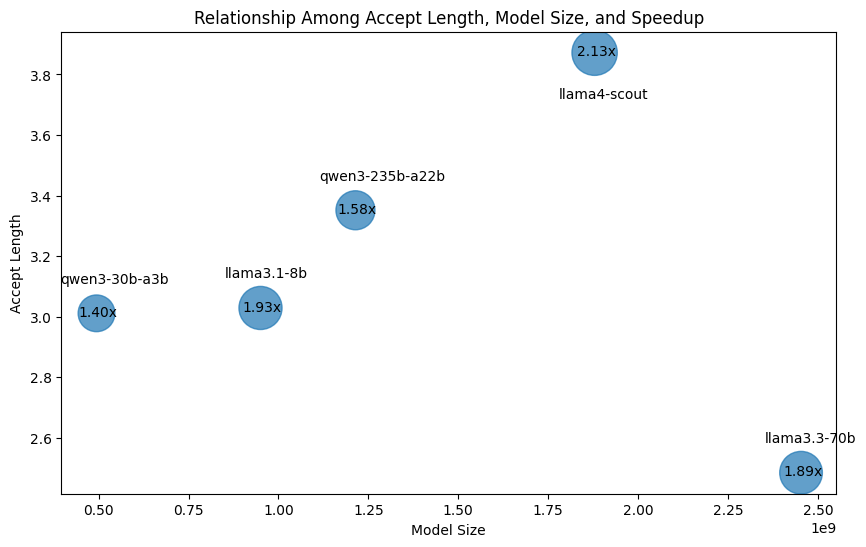

In [86]:
# plot a point graph of the speedup vs the accept length
import matplotlib.pyplot as plt

# Extract data for plotting
models = list(formatted_results.keys())

# we use the speedup as the size of the point
# x axis is the model size
# y axis is the accept length
# the size of the point is the speedup
speedups = [formatted_results[model]['speedup'] for model in models]
accept_lengths = [formatted_results[model]['accept_length'] for model in models]
model_sizes = [formatted_results[model]['model_size'] for model in models]


# scale the speedup by 10x
scaled_speedups = [x * 500 for x in speedups]

# create a plot
plt.figure(figsize=(10, 6))
plt.scatter(model_sizes, accept_lengths, s=scaled_speedups, alpha=0.7)
plt.xlabel('Model Size')
plt.ylabel('Accept Length')
plt.title('Relationship Among Accept Length, Model Size, and Speedup')

# place the model name on the plot
for i, model in enumerate(models):
    if model == "llama4-scout":
        plt.text(model_sizes[i] - 100000000, accept_lengths[i]-0.15, model)
    else:
        plt.text(model_sizes[i] - 100000000, accept_lengths[i]+0.1, model)

# print the speedup on the bubble
for i, model in enumerate(models):
    plt.text(model_sizes[i] - 50000000, accept_lengths[i] - 0.01, f"{speedups[i]:.2f}x")


plt.savefig('figures/accept_length_vs_model_size.png', dpi=300)
plt.show()




